<div dir="rtl">
  <p style="color: #80f9fa; text-align: right;">
    <b>چرخه‌ی مدل‌سازی، آموزش و ارزیابی</b>
  </p>
</div>

---

<div dir="rtl" style="text-align: right;">
هدف از این بخش ساخت چرخه اولیه‌ای از انتخاب داده، ساخت مدل و بهینه‌سازی آن است.
</div>

---

Build Model:

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = Model()

<div dir="rtl" style="text-align: right;">
هایپرپارامترها
</div>

Hyper Parameters:

__Number of Epochs__ - the number of times to iterate over the dataset

__Batch Size__ - the number of data samples propagated through the network before the parameters are updated

__Learning Rate__ - how much to update models parameters at each batch/epoch. Smaller values yield slow learning speed, while large values may result in unpredictable behavior during training.

In [4]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

Optimization Loop:

we can then train and optimize our model with an __optimization loop__.

Each iteration of the optimization loop is called an __epoch__.

Each epoch consists of two main parts:

- The __Train Loop__ - iterate over the training dataset and try to converge to optimal parameters.

- The __Validation/Test Loop__ - iterate over the test dataset to check if model performance is improving.

```python
for epoch in range(epochs):
    for img, label in train_dataloader:
        pass    # iteration
    for img, label in val_loader:
        pass
```

<div dir="rtl" style="text-align: right;">
تابع هزینه:
</div>

Loss:

- nn.MSELoss (Mean Square Error)
- nn.NLLLoss (Negative Log Likelihood)
- nn.CrossEntropyLoss
- nn.BCEWithLogitsLoss()

In [ ]:
import torch.nn as nn
# nn.BCELoss
loss_fn = nn.CrossEntropyLoss()

<div dir="rtl" style="text-align: right;">
بهینه‌سازی پارامترها:
</div>

Optimizer:

- SGD
- Adam
- RMSProp
- ...

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
# momentum

Inside the training loop, optimization happens in three steps:

- Call __optimizer.zero_grad()__ to reset the gradients of model parameters. Gradients by default add up; to prevent double-counting, we explicitly zero them at each iteration.

- Backpropagate the prediction loss with a call to __loss.backward()__. PyTorch deposits the gradients of the loss w.r.t. each parameter.

- Once we have our gradients, we call __optimizer.step()__ to adjust the parameters by the gradients collected in the backward pass.

```python
for epoch in range(epochs):
    for img, label in train_dataloader:
        optimizer.zero_grad()
        # forward --> out = model(img)
        # loss --> loss = loss_fn(label, out)
        loss.backward()
        optimizer.step()
```

---

<div dir="rtl" style="text-align: right;">
ترکیب کدهای فوق برای آموزش مدل (صرف‌نظر از ارزیابی‌ها و بخش تست):
</div>

In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = Model()

learning_rate = 1e-3
batch_size = 64
epochs = 5

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

###################

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
# out = model(img.to(device))


from tqdm import tqdm

L = []
Ltest = []
for epoch in range(epochs):
    for img, label in tqdm(train_dataloader):
        optimizer.zero_grad()

        x = img.to(device)
        label = label.to(device)
        y = model(x)
        loss = loss_fn(y, label)
        L.append(loss.item())

        loss.backward()
        optimizer.step()

    for img, label in tqdm(test_dataloader):
        x = img.to(device)
        label = label.to(device)
        y = model(x)
        loss = loss_fn(y, label)
        Ltest.append(loss.item())

100%|██████████| 157/157 [00:01<00:00, 136.63it/s]


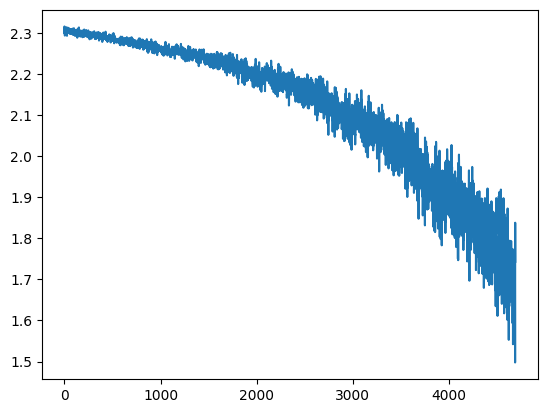

In [6]:
import matplotlib.pyplot as plt
plt.plot(L)

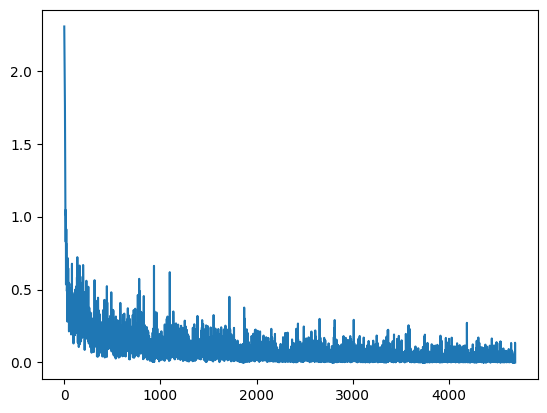

In [8]:
plt.plot(L)

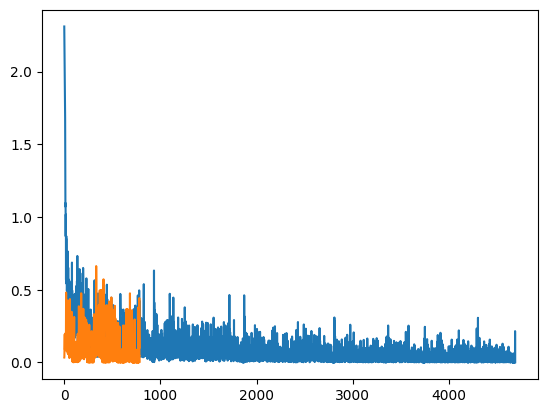

In [10]:
plt.plot(L)
plt.plot(Ltest)

tensorboard

<div dir="rtl" style="text-align: right;">
رسم ماتریس کانفیوژن:
</div>

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [12]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for img, label in test_dataloader:
        img = img.to(device)

        outputs = model(img)

        # outputs [batch_size, 10]
        # pred = outputs.argmax(dim=1)

        pred = outputs.argmax(dim=1)

        y_true.extend(label.numpy())
        y_pred.extend(pred.cpu().numpy())

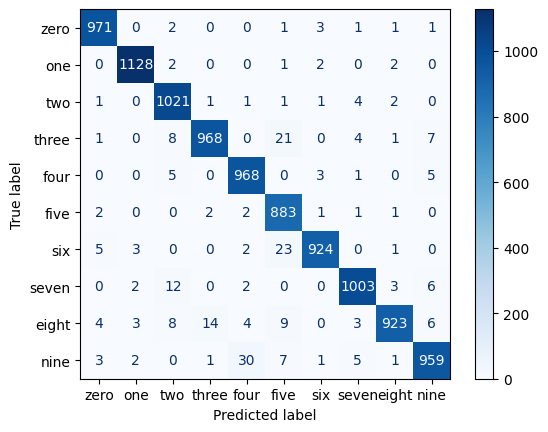

In [14]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
)

disp.plot(cmap="Blues", values_format="d")
plt.show()

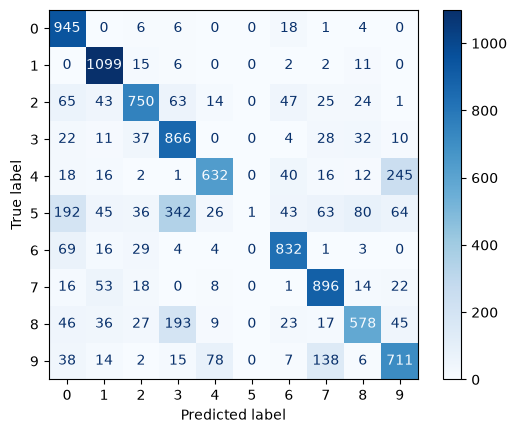

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues", values_format="d")
plt.show()

<div dir="rtl" style="text-align: right;">
محاسبه دقت:
</div>

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)

print(acc)

0.731


In [15]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)

print(acc)

0.9748


---

<div dir="rtl" style="text-align: right;">
قالب‌بندی چرخه آموزش و ارزیابی در توابعی مجزا:
</div>

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 1.595574  [   64/60000]
loss: 1.541324  [ 6464/60000]
loss: 1.609007  [12864/60000]
loss: 1.397029  [19264/60000]
loss: 1.418611  [25664/60000]
loss: 1.407626  [32064/60000]
loss: 1.340102  [38464/60000]
loss: 1.482612  [44864/60000]
loss: 1.317724  [51264/60000]
loss: 1.296466  [57664/60000]
Test Error: 
 Accuracy: 77.5%, Avg loss: 1.258195 

Epoch 2
-------------------------------
loss: 1.296087  [   64/60000]
loss: 1.212400  [ 6464/60000]
loss: 1.281533  [12864/60000]
loss: 1.104208  [19264/60000]
loss: 1.110016  [25664/60000]
loss: 1.094376  [32064/60000]
loss: 1.039652  [38464/60000]
loss: 1.205266  [44864/60000]
loss: 1.069846  [51264/60000]
loss: 1.037997  [57664/60000]
Test Error: 
 Accuracy: 80.0%, Avg loss: 0.999745 

Epoch 3
-------------------------------
loss: 1.061505  [   64/60000]
loss: 0.965267  [ 6464/60000]
loss: 1.021093  [12864/60000]
loss: 0.900369  [19264/60000]
loss: 0.892814  [25664/60000]
loss: 0.877034  [32064/600